# Farmetry 데이터 적용 — 이미지 생장량 + 다음 적정 온·습도

- **셀 3**: 초록 마스크 → **생장량(g/일)** 추정 (시간순 이미지 간 변화)
- **셀 4**: **최신 이미지** 기준 Ridge + Optuna **온·습도 권고** + **생장 증가율(%)**


In [26]:
# 데이터 로드 · 이미지 매칭
import sys
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

KST = timezone(timedelta(hours=9))
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FARMETRY = ROOT
DATA_DIR = FARMETRY / "data" / "farmetry"
IMG_DIR = DATA_DIR / "Farmetry_image"
OUT = DATA_DIR
SCRIPTS = FARMETRY / "scripts"
sys.path.insert(0, str(SCRIPTS))

EXCEL_PATH = next(DATA_DIR.glob("*.xlsx"))
N_TRIALS = 120


def _row_datetime(row: pd.Series) -> pd.Timestamp:
    if pd.notna(row.get("image_id")):
        ts = datetime.fromtimestamp(int(row["image_id"]), tz=KST)
        return pd.Timestamp(ts.replace(tzinfo=None))
    d = pd.to_datetime(row["date"])
    t = row["time"]
    if pd.isna(t):
        return pd.NaT
    if hasattr(t, "time"):
        return pd.Timestamp.combine(d.date(), t.time())
    return pd.to_datetime(f"{d.date()} {t}")


raw = pd.read_excel(EXCEL_PATH)
raw.columns = ["date", "time", "image_id", "temp_c", "humidity_pct"]
raw["datetime"] = raw.apply(_row_datetime, axis=1)
raw["date_only"] = pd.to_datetime(raw["datetime"]).dt.date

img_paths = {int(p.stem): p for p in IMG_DIR.rglob("*.jpg")}
raw["image_path"] = raw["image_id"].apply(
    lambda x: str(img_paths[int(x)].relative_to(FARMETRY)) if pd.notna(x) and int(x) in img_paths else None
)

excel_ids = set(raw["image_id"].dropna().astype(int))
matched = excel_ids & set(img_paths)
print(f"엑셀: {EXCEL_PATH.name} | 시간별 {len(raw)}행")
print(f"이미지 {len(img_paths)}장 | 엑셀 ID 매칭 {len(matched)}/{len(excel_ids)}")

daily = (
    raw.dropna(subset=["datetime"])
    .groupby("date_only", as_index=False)
    .agg(
        AirTemp_C_min=("temp_c", "min"),
        AirHum_pct_min=("humidity_pct", "min"),
        n_hours=("temp_c", "count"),
        image_ids=("image_id", lambda s: [int(x) for x in s.dropna().astype(int)]),
    )
)
daily["date"] = daily["date_only"].astype(str)
daily.to_csv(OUT / "office_env_daily.csv", index=False, encoding="utf-8-sig")
print("\n=== 일별 온습도 ===")
print(daily[["date", "AirTemp_C_min", "AirHum_pct_min", "n_hours"]].to_string(index=False))

snapshots = raw[raw["image_id"].notna()].copy()
snapshots["image_id"] = snapshots["image_id"].astype(int)
print("\n=== 이미지 촬영 시점 ===")
print(
    snapshots[["image_id", "datetime", "temp_c", "humidity_pct", "image_path"]]
    .rename(columns={"temp_c": "기온", "humidity_pct": "습도"})
    .to_string(index=False)
)

엑셀: 사무실 온습도 데이터.xlsx | 시간별 61행
이미지 32장 | 엑셀 ID 매칭 4/4

=== 일별 온습도 ===
      date  AirTemp_C_min  AirHum_pct_min  n_hours
2026-07-01           23.1            58.0       15
2026-07-02           22.7            56.0       24
2026-07-03           22.9            61.0       19

=== 이미지 촬영 시점 ===
  image_id            datetime   기온   습도                                  image_path
1782864001 2026-07-01 09:00:01 25.7 71.0 data\farmetry\Farmetry_image\1782864001.jpg
1782914401 2026-07-01 23:00:01 28.2 59.0 data\farmetry\Farmetry_image\1782914401.jpg
1782986400 2026-07-02 19:00:00 26.8 66.0 data\farmetry\Farmetry_image\1782986400.jpg
1783072801 2026-07-03 19:00:01 26.1  NaN data\farmetry\Farmetry_image\1783072801.jpg


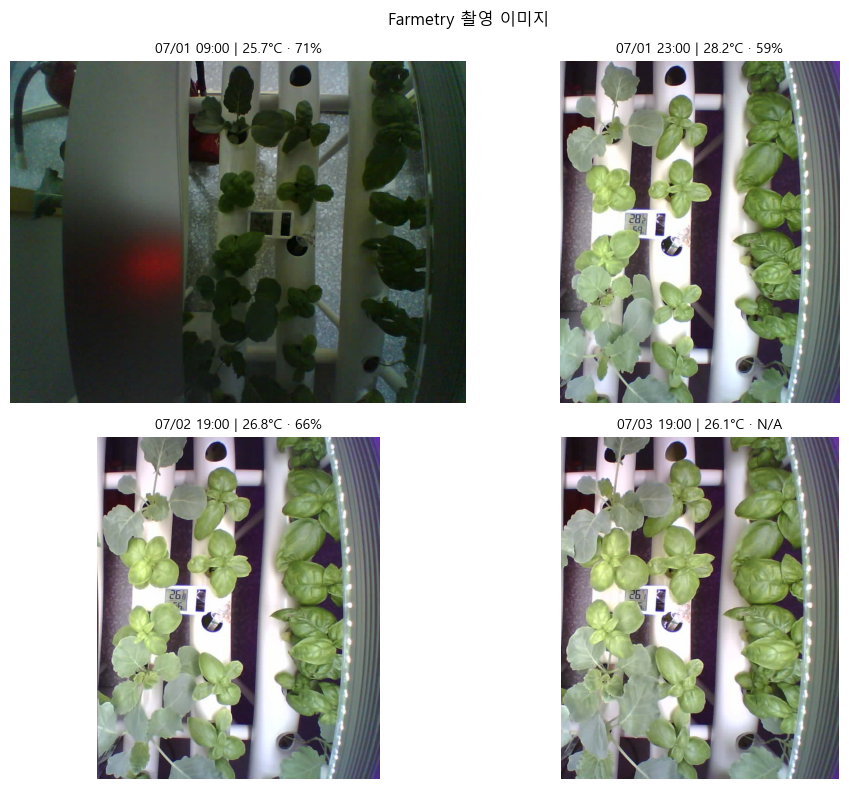

In [27]:
# 엑셀 매칭 이미지 4장 시각화
from PIL import Image

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (_, row) in zip(axes.ravel(), snapshots.sort_values("datetime").iterrows()):
    ax.imshow(Image.open(FARMETRY / row["image_path"]).convert("RGB"))
    hum = f"{row['humidity_pct']:.0f}%" if pd.notna(row["humidity_pct"]) else "N/A"
    ax.set_title(
        f"{row['datetime'].strftime('%m/%d %H:%M')} | {row['temp_c']:.1f}°C · {hum}",
        fontsize=10,
    )
    ax.axis("off")

plt.suptitle("Farmetry 촬영 이미지", fontsize=12)
plt.tight_layout()
plt.show()

분석 대상: 3장 (제외: [1782864001])

캘리브레이션 (상추 21일): G_PER_PX=7.58e-05 g/px, G_ABS_PER_PX=8.10e-05 g/px

=== 이미지별 녹색 마스크 · 식생지수 ===
  image_id            datetime  green_area_px  green_cover_ratio  mean_ExG  mean_GLI  mean_NGRDI  greenness
1782914401 2026-07-01 23:00:01         146795             0.3044  0.312716  0.160624    0.092009   0.188450
1782986400 2026-07-02 19:00:00         162914             0.3346  0.292033  0.140473    0.077081   0.169862
1783072801 2026-07-03 19:00:01         187406             0.3911  0.282797  0.136225    0.066346   0.161789

=== 초록 마스크 기준 생장량 추정 ===
  image_id            datetime  green_area_px  proxy_biomass_g  delta_green_px  interval_days  est_g_per_day
1782914401 2026-07-01 23:00:01         146795           11.887             NaN            NaN            NaN
1782986400 2026-07-02 19:00:00         162914           13.192         16119.0       0.833322          1.467
1783072801 2026-07-03 19:00:01         187406           15.176         24492.0       1.00

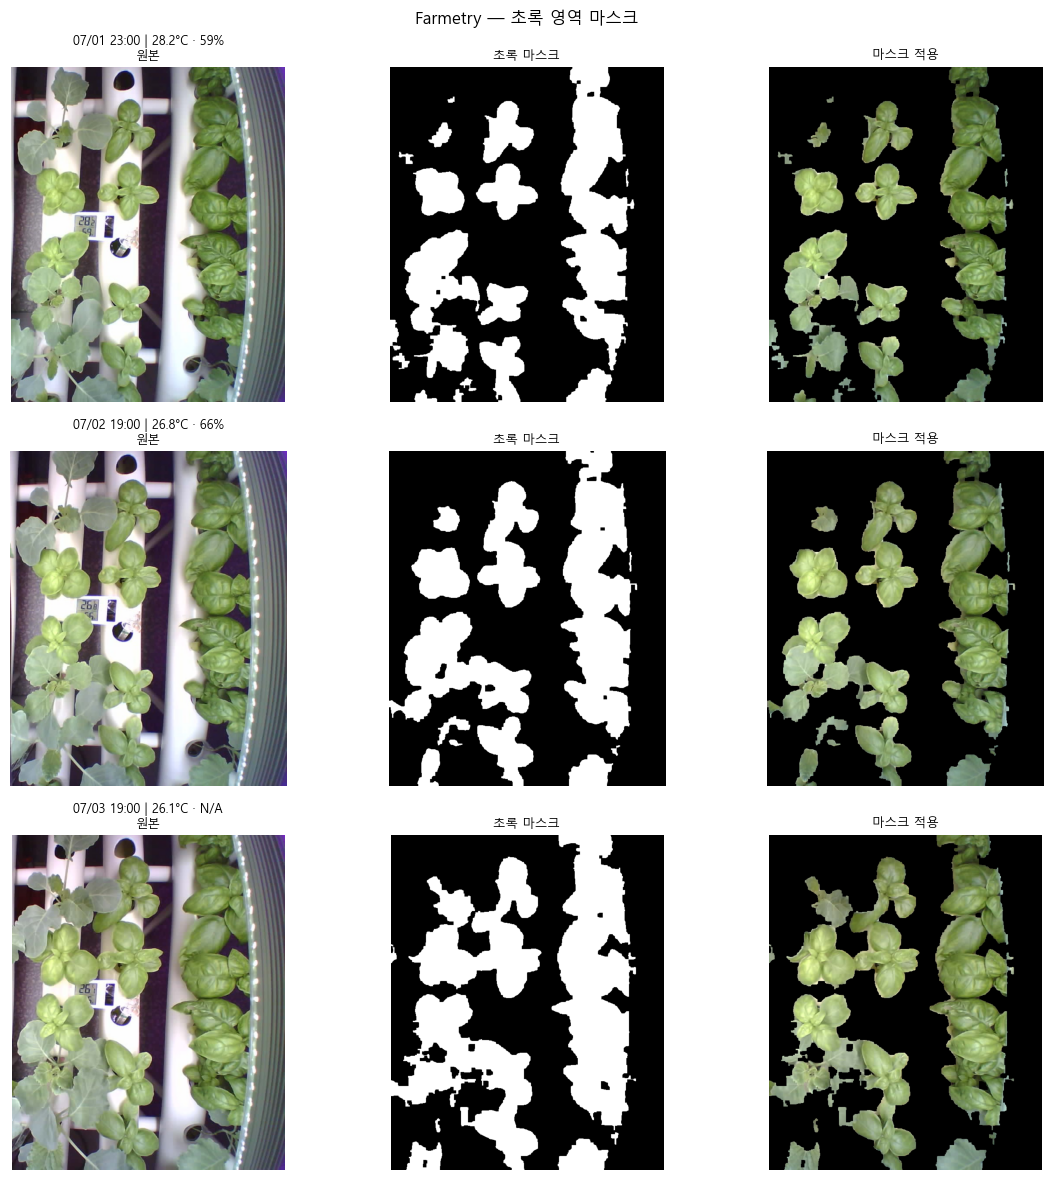

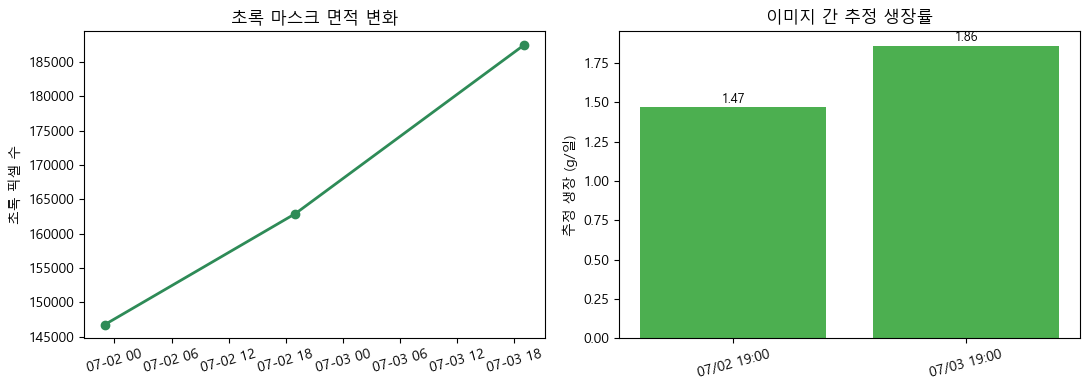

In [28]:
# 초록 영역 마스크 + 잎 크기 · 식생지수 · 생장량(g) 추정 (1782864001 제외)
import cv2
import numpy as np

MIN_AREA = 150
EXCLUDE_IDS = {1782864001}
LETTUCE_CANOPY_CSV = FARMETRY / "data" / "lettuce_processed" / "daily_merged_bio_env_canopy.csv"


def build_green_mask(img_bgr: np.ndarray) -> np.ndarray:
    """HSV + ExG로 초록 영역 마스크."""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask_hsv = cv2.inRange(hsv, np.array([25, 35, 25]), np.array([95, 255, 255]))
    b, g, r = cv2.split(img_bgr.astype(np.float32))
    exg = 2 * g - r - b
    exg_norm = cv2.normalize(exg, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, mask_exg = cv2.threshold(exg_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    mask = cv2.bitwise_and(mask_hsv, mask_exg)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    return mask


def clean_green_mask(mask: np.ndarray) -> np.ndarray:
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    clean = np.zeros(mask.shape, dtype=np.uint8)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= MIN_AREA:
            clean[labels == i] = 255
    return clean


def vegetation_indices(img_bgr: np.ndarray) -> dict[str, np.ndarray]:
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    r, g, b = rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2]
    eps = 1e-6
    gli = (2 * g - r - b) / (2 * g + r + b + eps)
    ngrdi = (g - r) / (g + r + eps)
    return {"ExG": 2 * g - r - b, "GLI": np.clip(gli, -1, 1), "NGRDI": np.clip(ngrdi, -1, 1)}


def mean_indices(img_bgr: np.ndarray, mask: np.ndarray) -> dict[str, float]:
    valid = mask > 0
    if not valid.any():
        return {k: np.nan for k in ["mean_ExG", "mean_GLI", "mean_NGRDI", "greenness"]}
    idx = vegetation_indices(img_bgr)
    means = {f"mean_{k}": float(v[valid].mean()) for k, v in idx.items()}
    means["greenness"] = float(np.mean([means["mean_ExG"], means["mean_GLI"], means["mean_NGRDI"]]))
    return means


def masked_image(img_bgr: np.ndarray, mask: np.ndarray) -> np.ndarray:
    out = np.zeros_like(img_bgr)
    out[mask > 0] = img_bgr[mask > 0]
    return out


canopy_targets = snapshots[~snapshots["image_id"].isin(EXCLUDE_IDS)].sort_values("datetime")
canopy_rows, viz_cache = [], []

for _, snap in canopy_targets.iterrows():
    img_id = int(snap["image_id"])
    img = cv2.imread(str(FARMETRY / snap["image_path"]))
    mask = clean_green_mask(build_green_mask(img))
    canopy_rows.append({
        "image_id": img_id,
        "datetime": snap["datetime"],
        "green_area_px": int((mask > 0).sum()),
        "green_cover_ratio": round((mask > 0).mean(), 4),
        **mean_indices(img, mask),
    })
    viz_cache.append((snap, img, mask))

canopy_df = pd.DataFrame(canopy_rows).sort_values("datetime").reset_index(drop=True)

# --- 상추 온실 캘리브레이션: 초록 픽셀 → 생장량(g) ---
cal = pd.read_csv(LETTUCE_CANOPY_CSV)
pos = cal[
    (cal["delta_total_leaf_area_px"] > 0)
    & (cal["biomass_delta_g_mean"] > 0)
    & cal["delta_total_leaf_area_px"].notna()
    & cal["biomass_delta_g_mean"].notna()
]
G_PER_PX = float((pos["biomass_delta_g_mean"] / pos["delta_total_leaf_area_px"]).median())
G_ABS_PER_PX = float(
    (cal.loc[cal["total_leaf_area_px"] > 0, "biomass_g_mean"]
     / cal.loc[cal["total_leaf_area_px"] > 0, "total_leaf_area_px"]).median()
)

canopy_df["proxy_biomass_g"] = (canopy_df["green_area_px"] * G_ABS_PER_PX).round(3)
canopy_df["delta_green_px"] = canopy_df["green_area_px"].diff()
canopy_df["interval_days"] = canopy_df["datetime"].diff().dt.total_seconds() / 86400
canopy_df["est_g_per_day"] = np.where(
    canopy_df["interval_days"] > 0,
    G_PER_PX * canopy_df["delta_green_px"] / canopy_df["interval_days"],
    np.nan,
).round(3)

canopy_df.to_csv(OUT / "office_canopy_summary.csv", index=False, encoding="utf-8-sig")
growth_df = canopy_df[
    ["image_id", "datetime", "green_area_px", "proxy_biomass_g", "delta_green_px", "interval_days", "est_g_per_day"]
].copy()
growth_df.to_csv(OUT / "office_image_growth.csv", index=False, encoding="utf-8-sig")

print(f"분석 대상: {len(canopy_targets)}장 (제외: {sorted(EXCLUDE_IDS)})")
print(f"\n캘리브레이션 (상추 {len(pos)}일): G_PER_PX={G_PER_PX:.2e} g/px, G_ABS_PER_PX={G_ABS_PER_PX:.2e} g/px")
print("\n=== 이미지별 녹색 마스크 · 식생지수 ===")
print(canopy_df[
    ["image_id", "datetime", "green_area_px", "green_cover_ratio",
     "mean_ExG", "mean_GLI", "mean_NGRDI", "greenness"]
].to_string(index=False))
print("\n=== 초록 마스크 기준 생장량 추정 ===")
print(growth_df.to_string(index=False))
print(f"\n저장: {OUT / 'office_canopy_summary.csv'}")
print(f"저장: {OUT / 'office_image_growth.csv'}")
print("※ g/일은 상추 온실 캘리브레이션 기반 추정치이며, 저울 실측이 아닙니다.")

n = len(viz_cache)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1:
    axes = np.array([axes])
for row, (snap, img, mask) in enumerate(viz_cache):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    masked_rgb = cv2.cvtColor(masked_image(img, mask), cv2.COLOR_BGR2RGB)
    hum = f"{snap['humidity_pct']:.0f}%" if pd.notna(snap["humidity_pct"]) else "N/A"
    title = f"{snap['datetime'].strftime('%m/%d %H:%M')} | {snap['temp_c']:.1f}°C · {hum}"

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f"{title}\n원본", fontsize=9)
    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("초록 마스크", fontsize=9)
    axes[row, 2].imshow(masked_rgb)
    axes[row, 2].set_title("마스크 적용", fontsize=9)
    for ax in axes[row]:
        ax.axis("off")

plt.suptitle("Farmetry — 초록 영역 마스크", fontsize=12)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(canopy_df["datetime"], canopy_df["green_area_px"], "o-", color="seagreen", lw=2)
axes[0].set_ylabel("초록 픽셀 수")
axes[0].set_title("초록 마스크 면적 변화")
axes[0].tick_params(axis="x", rotation=15)

g_days = canopy_df.dropna(subset=["est_g_per_day"])
axes[1].bar(
    g_days["datetime"].dt.strftime("%m/%d %H:%M"),
    g_days["est_g_per_day"],
    color="#4caf50",
)
axes[1].set_ylabel("추정 생장 (g/일)")
axes[1].set_title("이미지 간 추정 생장률")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(g_days["est_g_per_day"]):
    axes[1].text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


기준: 최신 이미지 07/03 19:00 (ID 1783072801) | 기온 26.1°C, 습도 61.0% (해당일 일 최저 습도 (이미지 습도 없음))
모델: Ridge (CV) | 탐색: optuna (120 trials) | 상추 학습 범위 p10~p90

=== 다음 적정 온·습도 (최신 이미지 기준) ===
현재  : 기온 26.1°C, 습도 61.0%
다음  : 기온 25.6°C (낮추는 방향), 습도 58.0% (낮추는 방향)
장기  : 기온 18.98°C, 습도 34.41%
예측 생장 증가율: 다음 제어 +3.59% | 장기 목표 +18.72% (Ridge, 현재 환경 대비)
※ 절대 생장량(g/일)은 셀 3 초록 마스크 기준 | 위 %는 환경모델 상대 개선율
※ 사무실 습도(56~77%)는 학습 범위(34~47%)보다 높음 → 습도 낮추기 권고

저장: c:\Users\msyu7\Desktop\HYU\Farmetry-VisionAI\data\farmetry\office_control_recommendation.csv


,label,현재_기온,다음_기온,목표_기온,현재_습도,다음_습도,목표_습도,다음_생장_증가_%,목표_생장_증가_%
0,최신 이미지 07/03 19:00 (ID 1783072801),26.1,25.6,18.98,61.0,58.0,34.41,3.59,18.72


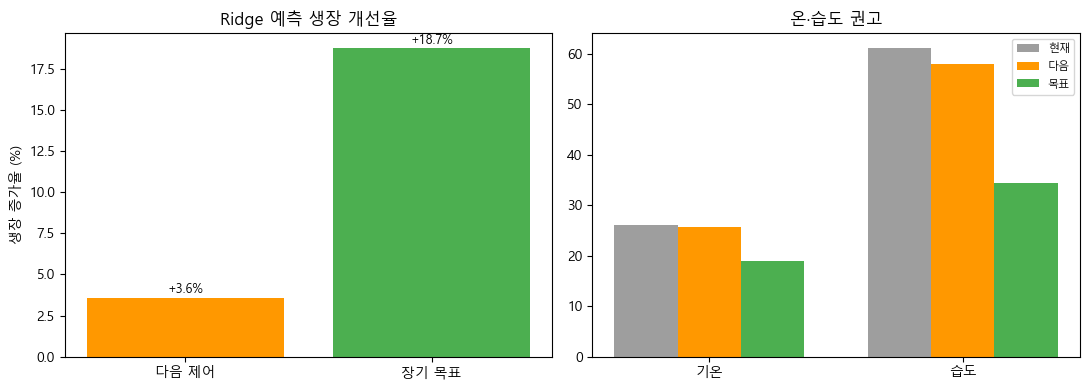

In [30]:
# Ridge 환경모델 + Optuna — 최신 이미지 기준 온·습도 권고 + 예측 생장 증가율(%)
from lettuce_growth_env_optuna import run_env_control_optuna
from lettuce_growth_model import load_merged, train_growth_model

merged = load_merged()
bundle, lag_df = train_growth_model(merged)
CONTROL = ["AirHum_pct_min", "AirTemp_C_min"]


def _growth_pct(new_g: float, base_g: float) -> float:
    if not base_g:
        return 0.0
    return round((new_g - base_g) / abs(base_g) * 100, 2)


def recommend_office(temp_min: float, hum_min: float, label: str) -> dict:
    res = run_env_control_optuna(
        bundle=bundle,
        lag_df=lag_df,
        merged=merged,
        n_trials=N_TRIALS,
        control_features=CONTROL,
        env_override={"AirTemp_C_min": float(temp_min), "AirHum_pct_min": float(hum_min)},
        scenario_name=label,
        verbose=False,
    )
    ctrl = res["control_df"].set_index("feature")
    cur_g, next_g, tgt_g = res["current_pred_g"], res["next_pred_g"], res["target_pred_g"]
    return {
        "label": label,
        "method": res["search_method"],
        "현재_기온": round(ctrl.loc["AirTemp_C_min", "current_value"], 2),
        "다음_기온": round(ctrl.loc["AirTemp_C_min", "next_control_value"], 2),
        "목표_기온": round(ctrl.loc["AirTemp_C_min", "bayesian_target"], 2),
        "현재_습도": round(ctrl.loc["AirHum_pct_min", "current_value"], 2),
        "다음_습도": round(ctrl.loc["AirHum_pct_min", "next_control_value"], 2),
        "목표_습도": round(ctrl.loc["AirHum_pct_min", "bayesian_target"], 2),
        "기온_조언": ctrl.loc["AirTemp_C_min", "advice"],
        "습도_조언": ctrl.loc["AirHum_pct_min", "advice"],
        "다음_생장_증가_%": _growth_pct(next_g, cur_g),
        "목표_생장_증가_%": _growth_pct(tgt_g, cur_g),
    }


latest = snapshots.sort_values("datetime").iloc[-1]
snap_dt = latest["datetime"]
temp = float(latest["temp_c"])
if pd.notna(latest["humidity_pct"]):
    hum = float(latest["humidity_pct"])
    hum_note = "이미지 촬영 시점 습도"
else:
    snap_date = pd.to_datetime(snap_dt).strftime("%Y-%m-%d")
    day_row = daily[daily["date"] == snap_date]
    hum = float(day_row.iloc[-1]["AirHum_pct_min"]) if len(day_row) else float(daily.iloc[-1]["AirHum_pct_min"])
    hum_note = "해당일 일 최저 습도 (이미지 습도 없음)"

label = f"최신 이미지 {snap_dt.strftime('%m/%d %H:%M')} (ID {int(latest['image_id'])})"
rec_df = pd.DataFrame([recommend_office(temp, hum, label)])
rec_df.to_csv(OUT / "office_control_recommendation.csv", index=False, encoding="utf-8-sig")

main = rec_df.iloc[0]
print(f"기준: {label} | 기온 {temp:.1f}°C, 습도 {hum:.1f}% ({hum_note})")
print(f"모델: Ridge (CV) | 탐색: {main['method']} ({N_TRIALS} trials) | 상추 학습 범위 p10~p90")
print("\n=== 다음 적정 온·습도 (최신 이미지 기준) ===")
print(f"현재  : 기온 {main['현재_기온']}°C, 습도 {main['현재_습도']}%")
print(f"다음  : 기온 {main['다음_기온']}°C ({main['기온_조언']}), 습도 {main['다음_습도']}% ({main['습도_조언']})")
print(f"장기  : 기온 {main['목표_기온']}°C, 습도 {main['목표_습도']}%")
print(
    f"예측 생장 증가율: 다음 제어 +{main['다음_생장_증가_%']}% | "
    f"장기 목표 +{main['목표_생장_증가_%']}% (Ridge, 현재 환경 대비)"
)
print("※ 절대 생장량(g/일)은 셀 3 초록 마스크 기준 | 위 %는 환경모델 상대 개선율")
print("※ 사무실 습도(56~77%)는 학습 범위(34~47%)보다 높음 → 습도 낮추기 권고")
print(f"\n저장: {OUT / 'office_control_recommendation.csv'}")

show = rec_df[
    [
        "label", "현재_기온", "다음_기온", "목표_기온",
        "현재_습도", "다음_습도", "목표_습도",
        "다음_생장_증가_%", "목표_생장_증가_%",
    ]
]
display(show)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
m = rec_df.iloc[0]

axes[0].bar(
    ["다음 제어", "장기 목표"],
    [m["다음_생장_증가_%"], m["목표_생장_증가_%"]],
    color=["#ff9800", "#4caf50"],
)
axes[0].set_ylabel("생장 증가율 (%)")
axes[0].set_title("Ridge 예측 생장 개선율")
for i, v in enumerate([m["다음_생장_증가_%"], m["목표_생장_증가_%"]]):
    axes[0].text(i, v + 0.3, f"+{v:.1f}%", ha="center", fontsize=9)

cats = ["기온", "습도"]
x = np.arange(2)
w = 0.25
axes[1].bar(x - w, [m["현재_기온"], m["현재_습도"]], w, label="현재", color="#9e9e9e")
axes[1].bar(x, [m["다음_기온"], m["다음_습도"]], w, label="다음", color="#ff9800")
axes[1].bar(x + w, [m["목표_기온"], m["목표_습도"]], w, label="목표", color="#4caf50")
axes[1].set_xticks(x)
axes[1].set_xticklabels(cats)
axes[1].set_title("온·습도 권고")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
